In [1]:
import numpy as np
import pandas as pd
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent  
sys.path.append(str(PROJECT_ROOT))

# Леса решений

## Классификация

In [18]:
df = pd.read_csv("../Data/WineQT.csv")

### Датасет WineQuality

In [4]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [5]:
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [6]:
df["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

In [7]:
df = df.drop(["Id"], axis=1)
df["quality"] -= 3

### Обучения ансамбля

In [ ]:
from ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [9]:
X = df.drop(["quality"], axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
model = RandomForestClassifier(max_depth=40)

In [11]:
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=40)

### Проверка модели и сравнение с sklearn

In [12]:
from sklearn.ensemble import RandomForestClassifier as RFC

In [13]:
model_rfc = RFC(max_depth=40)
model_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=40)

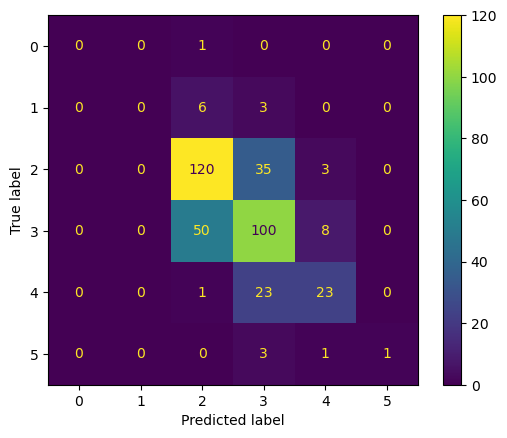

In [14]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

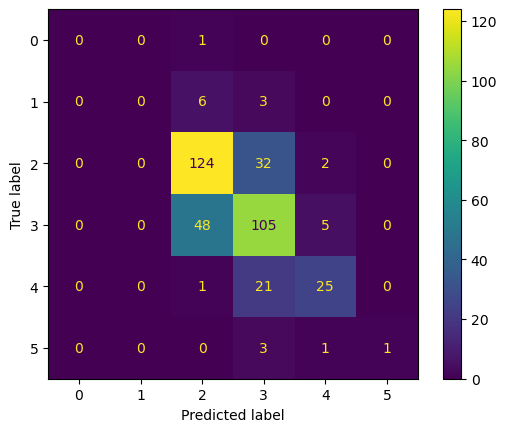

In [15]:
ConfusionMatrixDisplay.from_estimator(model_rfc, X_test, y_test)

In [16]:
y_pred = model.predict(X_test)
y_pred_r = model_rfc.predict(X_test)

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred_r))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.67      0.76      0.71       158
           3       0.61      0.63      0.62       158
           4       0.66      0.49      0.56        47
           5       1.00      0.20      0.33         5

    accuracy                           0.65       378
   macro avg       0.49      0.35      0.37       378
weighted avg       0.63      0.65      0.63       378

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.69      0.78      0.73       158
           3       0.64      0.66      0.65       158
           4       0.76      0.53      0.62        47
           5       1.00      0.20      0.33         5

    accuracy                           0.67       378
   macro avg       0.51

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packag

## Регрессия

In [7]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame

In [8]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Обучение ансамбля

In [20]:
from ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [21]:
X = df.drop(["MedHouseVal"], axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
model = RandomForestRegressor(max_depth=10)

In [23]:
model.fit(X_train, y_train)

RandomForestRegressor()

### Проверка модели и сравнение с sklearn

In [24]:
from sklearn.ensemble import RandomForestRegressor as RFR

In [25]:
model_ = RFR(max_depth=10)
model_.fit(X_train, y_train)

RandomForestRegressor(max_depth=10)

In [26]:
def print_metric(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R^2 = {r2}\nMAE = {mae}\nRMSE = {rmse}")

In [27]:
y_pred = model.predict(X_test)
print_metric(y_test, y_pred)

R^2 = 0.7523883581676822
MAE = 0.4104668423615588
RMSE = 0.574426015479354


In [29]:
y_pred = model_.predict(X_test)
print_metric(y_test, y_pred)

R^2 = 0.7745605598547289
MAE = 0.3720557918503656
RMSE = 0.5481046914284459


# Бустинг

## Классификация(бигарная)

In [1]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
df = data.frame

In [3]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


### Обучение ансамбля

In [4]:
from ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [5]:
X = df.drop(["target"], axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
model = GradientBoostingClassifier()

In [7]:
model.fit(X_train, y_train)

GradientBoostingClassifier()

### Проверка модели и сравнение с sklearn

In [8]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

In [10]:
model_ = GBC()
model_.fit(X_train, y_train)

GradientBoostingClassifier()

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        67
           1       0.97      0.97      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.96      0.96       188
weighted avg       0.96      0.96      0.96       188



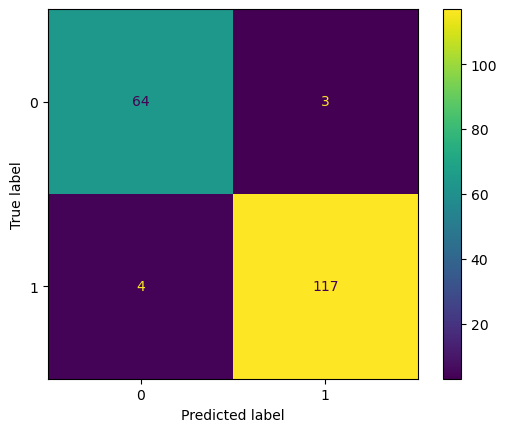

In [11]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        67
           1       0.96      0.98      0.97       121

    accuracy                           0.96       188
   macro avg       0.96      0.95      0.95       188
weighted avg       0.96      0.96      0.96       188



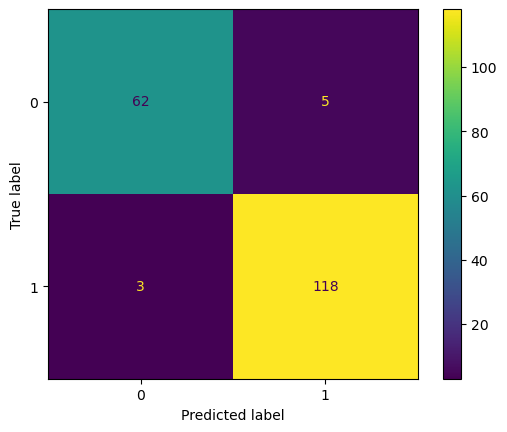

In [12]:
ConfusionMatrixDisplay.from_estimator(model_, X_test, y_test)
y_pred = model_.predict(X_test)
print(classification_report(y_test, y_pred))

## Классификация(многоклассовая)

In [2]:
df = pd.read_csv("../Data/WineQT.csv")

In [3]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [4]:
df = df.drop(["Id"], axis=1)
df["quality"] -= 3

### Обучение ансамбля

In [5]:
from ensemble import GradientBoostingMutliClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

In [6]:
X = df.drop(["quality"], axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [7]:
model = GradientBoostingMutliClassification()

In [8]:
model.fit(X_train, y_train)

GradientBoostingMutliClassification()

### Проверка модели и сравнение с sklearn

In [9]:
from sklearn.ensemble import GradientBoostingClassifier as GBC

In [10]:
model_ = GBC()
model_.fit(X_train, y_train)

GradientBoostingClassifier()

c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\danil\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         9
           2       0.67      0.77      0.71       158
           3       0.59      0.61      0.60       158
           4       0.63      0.36      0.46        47
           5       0.00      0.00      0.00         5

    accuracy                           0.62       378
   macro avg       0.31      0.29      0.29       378
weighted avg       0.60      0.62      0.60       378



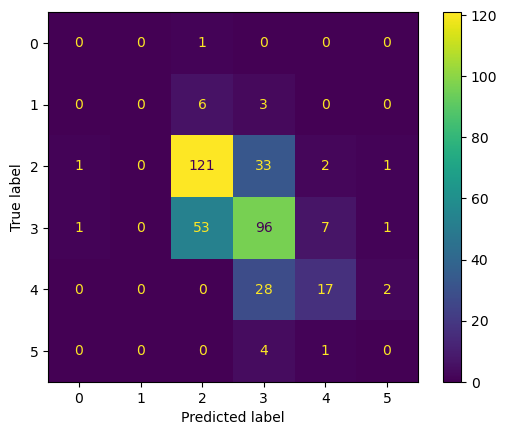

In [11]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.11      0.11      0.11         9
           2       0.69      0.72      0.70       158
           3       0.66      0.63      0.64       158
           4       0.63      0.57      0.60        47
           5       0.17      0.20      0.18         5

    accuracy                           0.64       378
   macro avg       0.38      0.37      0.37       378
weighted avg       0.64      0.64      0.64       378



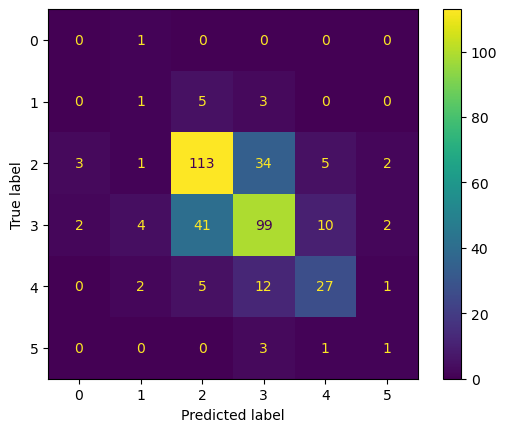

In [12]:
ConfusionMatrixDisplay.from_estimator(model_, X_test, y_test)
y_pred = model_.predict(X_test)
print(classification_report(y_test, y_pred))

## Регрессия

In [2]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame

In [3]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


### Обучение ансамбля

In [4]:
from ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [5]:
X = df.drop(["MedHouseVal"], axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [6]:
model = GradientBoostingRegressor()

In [7]:
model.fit(X_train, y_train)

GradientBoostingRegressor()

### Проверка модели и сравнение с sklearn

In [8]:
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [13]:
model_ = GBR(n_estimators=50, max_depth=3, min_samples_split=2, min_samples_leaf=1, random_state=42)
model_.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=50, random_state=42)

In [14]:
def print_metric(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R^2 = {r2}\nMAE = {mae}\nRMSE = {rmse}")

In [15]:
y_pred = model.predict(X_test)
print_metric(y_test, y_pred)

R^2 = 0.6673584593321154
MAE = 0.48742053148758935
RMSE = 0.6657893018793096


In [16]:
y_pred = model_.predict(X_test)
print_metric(y_test, y_pred)

R^2 = 0.7482096974531044
MAE = 0.4083675021690531
RMSE = 0.5792527050660395
